In [11]:
import pandas as pd
import spacy
import numpy as np
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
#from keras.regularizers import l2
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
from google.colab import files
uploaded = files.upload()

Saving twitter_data.csv to twitter_data.csv


In [3]:
df = pd.read_csv('/content/twitter_data.csv')

In [4]:
df.shape

(24783, 7)

In [5]:
df['class'] = df['class'].astype(int)
df['class'].value_counts()

,count
class,
1,19190
2,4163
0,1430


In [6]:
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [7]:
df.drop(columns = ['Unnamed: 0',	'count',	'hate_speech',	'offensive_language',	'neither'],
        inplace = True)

In [8]:
df.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [9]:
# 2. CHECKING FOR NULL VALUES
df.isna().sum()

,0
class,0
tweet,0


In [12]:
def clean_text(tweet):
    tweet = re.sub(r'RT\s+', '', tweet)
    tweet = re.sub(r'@\w+', '', tweet)
    tweet = re.sub(r'http\S+', '', tweet)
    tweet = re.sub(r'[!"$%&\'()*+,.\/:;<=>?@[\]^_`{|}~]', ' ', tweet)
    tweet = re.sub(r'\s+', ' ', tweet)
    return tweet.strip()

df['tweet'] = df['tweet'].astype(str).apply(clean_text)

In [13]:
df.head()

,class,tweet
0,2,As a woman you shouldn t complain about cleani...
1,1,boy dats cold tyga dwn bad for cuffin dat hoe ...
2,1,Dawg You ever fuck a bitch and she start to cr...
3,1,she look like a tranny
4,1,The shit you hear about me might be true or it...


In [14]:
# load out spacy modeule
nlp = spacy.load('en_core_web_sm')

In [15]:
# LEMMATIZATION
def lemmatization(text):
  doc = nlp(text)
  lemmaList = [word.lemma_ for word in doc]
  return ' '.join(lemmaList)

df['lemma_tweet'] = df['tweet'].apply(lemmatization)

In [16]:
df['tweet'].iloc[67]

'Lemmie eat a Oreo amp do these dishes One oreo Lol'

In [17]:
df['lemma_tweet'].iloc[67]

'Lemmie eat a Oreo amp do these dish one oreo lol'

In [18]:
#  REMOVING STOPWORDS
def remove_stopwords(text):
  doc = nlp(text)
  no_stopwords_list = [word.text for word in doc if not word.is_stop]
  return ' '.join(no_stopwords_list)

df['final_tweet'] = df['lemma_tweet'].apply(remove_stopwords)

In [19]:
df['final_tweet'].iloc[67]

'Lemmie eat Oreo amp dish oreo lol'

In [20]:
vocab_size = 10000
one_hot_representation = [one_hot(words, vocab_size) for words in df['final_tweet']]

In [21]:
df['final_tweet'].iloc[2]

'Dawg fuck bitch start cry confuse shit'

In [22]:
one_hot_representation[2]

[7963, 8730, 5916, 7626, 2006, 2886, 9406]

In [24]:
# PADDING AND EMBEDDING

sentence_length = 20
embedded_tweet = pad_sequences(one_hot_representation, padding='pre', maxlen = sentence_length)

In [25]:
embedded_tweet[2]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0, 7963, 8730, 5916, 7626, 2006, 2886, 9406], dtype=int32)

In [26]:
# DIVIDING THE DATASET
X = np.array(embedded_tweet)
y = np.array(df['class'])

In [27]:
smote = SMOTE(sampling_strategy='minority')
X, y = smote.fit_resample(X, y)

In [32]:
df['class'].value_counts()

,count
class,
1,19190
2,4163
0,1430


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [33]:
X_train.shape, X_test.shape

((34034, 20), (8509, 20))

In [36]:
# MODEL

dimension = 50

model = keras.Sequential([
    #embedding layer
    keras.layers.Embedding(vocab_size, dimension),
    # LSTM layer
    keras.layers.LSTM(100,return_sequences=True),
    keras.layers.LSTM(50, return_sequences=True),
    keras.layers.LSTM(50),
    #output layer
    keras.layers.Dense(3, activation = 'softmax')
])

#compilation
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [37]:
model.build(input_shape=(None, sentence_length))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 20, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 20, 100)        │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 20, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 610,953 (2.33 MB)

 Trainable params: 610,953 (2.33 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.fit(X_train, y_train, epochs = 10, batch_size=32)

Epoch 1/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - accuracy: 0.8583 - loss: 0.3695
Epoch 2/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - accuracy: 0.9371 - loss: 0.1919
Epoch 3/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - accuracy: 0.9545 - loss: 0.1414
Epoch 4/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - accuracy: 0.9653 - loss: 0.1160
Epoch 5/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.9709 - loss: 0.0982
Epoch 6/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.9752 - loss: 0.0840
Epoch 7/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 50s 47ms/step - accuracy: 0.9792 - loss: 0.0709
Epoch 8/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 48s 45ms/step - accuracy: 0.9818 - loss: 0.0601
Epoch 9/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 85s 48ms/step - accuracy: 0.9839 - loss: 0.0512
Epoch 10/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 79s 45ms/step - accuracy: 0.9862 - loss: 0.0420


In [39]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Model Accuracy : {accuracy * 100}')

266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8982 - loss: 0.4777
Model Accuracy : 89.82254266738892


In [40]:
pred = np.argmax(model.predict(X_test), axis = -1)

266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


In [41]:
y_test[:5]

array([1, 1, 0, 1, 2])

In [42]:
pred[:5]

array([1, 1, 0, 1, 2])

In [43]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      3812
           1       0.91      0.93      0.92      3807
           2       0.73      0.74      0.74       890

    accuracy                           0.90      8509
   macro avg       0.86      0.86      0.86      8509
weighted avg       0.90      0.90      0.90      8509



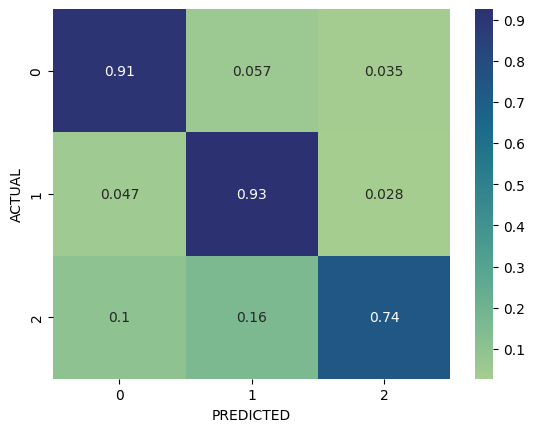

In [44]:
cf = confusion_matrix(y_test, pred, normalize = 'true')
sns.heatmap(cf, annot = True, cmap = 'crest')
plt.xlabel('PREDICTED'),
plt.ylabel('ACTUAL');

In [47]:
import json

id2label = {0: "HATE", 1: "OFFENSIVE", 2: "NEITHER"}
label2id = {"HATE": 0, "OFFENSIVE": 1, "NEITHER": 2}

# Save id2label mapping
with open("/content/id2label.json", "w") as f:
    json.dump(id2label, f)

# Save label2id mapping
with open("/content/label2id.json", "w") as f:
    json.dump(label2id, f)

model.save("/content/rnn-hate-speech-model.keras")

In [49]:
from google.colab import drive
drive.mount('/drive')

import shutil
shutil.copy(
    '/content/rnn-hate-speech-model.keras',
    '/drive/MyDrive/rnn-hate-speech-model.keras'
)

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).


'/drive/MyDrive/rnn-hate-speech-model.keras'

In [51]:
import shutil
from google.colab import files

# Define the files/directories to be zipped
files_to_zip = [
    '/content/rnn-hate-speech-model.keras',
    '/content/id2label.json',
    '/content/label2id.json'
]

# Create a temporary directory to place the files before zipping
import os
temp_dir = '/content/model_and_metadata'
os.makedirs(temp_dir, exist_ok=True)

for f_path in files_to_zip:
    shutil.copy(f_path, temp_dir)

# Create the zip archive
shutil.make_archive('/content/rnn_hate_speech_model_package', 'zip', temp_dir)

# Download the zip file
files.download('/content/rnn_hate_speech_model_package.zip')

# Clean up the temporary directory
shutil.rmtree(temp_dir)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
def preprocess_and_predict(text):
    # 1. Clean text
    cleaned_text = clean_text(text)

    # 2. Lemmatize text
    lemmatized_text = lemmatization(cleaned_text)

    # 3. Remove stopwords
    final_text = remove_stopwords(lemmatized_text)

    # 4. One-hot encode
    one_hot_encoded = one_hot(final_text, vocab_size)

    # 5. Pad sequence
    padded_sequence = pad_sequences([one_hot_encoded], padding='pre', maxlen=sentence_length)

    # 6. Predict
    prediction_probabilities = model.predict(padded_sequence)
    predicted_class_id = np.argmax(prediction_probabilities)

    # 7. Map to label
    predicted_label = id2label[predicted_class_id]

    return predicted_label, prediction_probabilities

# Example usage:
example_tweet = "This is a great day, I love coding!"
predicted_label, probs = preprocess_and_predict(example_tweet)
print(f"Example Tweet: '{example_tweet}'")
print(f"Predicted Class: {predicted_label}")
print(f"Prediction Probabilities: {probs}")

example_tweet_2 = "You are so dumb, I hate you!"
predicted_label_2, probs_2 = preprocess_and_predict(example_tweet_2)
print(f"\nExample Tweet: '{example_tweet_2}'")
print(f"Predicted Class: {predicted_label_2}")
print(f"Prediction Probabilities: {probs_2}")

example_tweet_3 = "I will beat you up. You are ugly."
predicted_label_3, probs_3 = preprocess_and_predict(example_tweet_3)
print(f"\nExample Tweet: '{example_tweet_3}'")
print(f"Predicted Class: {predicted_label_3}")
print(f"Prediction Probabilities: {probs_3}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Example Tweet: 'This is a great day, I love coding!'
Predicted Class: NEITHER
Prediction Probabilities: [[0.07664151 0.00428305 0.9190754 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

Example Tweet: 'You are so dumb, I hate you!'
Predicted Class: OFFENSIVE
Prediction Probabilities: [[0.4064286  0.46301174 0.13055968]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

Example Tweet: 'I will beat you up. You are ugly.'
Predicted Class: HATE
Prediction Probabilities: [[9.9741566e-01 1.7852294e-03 7.9909037e-04]]


In [53]:
example_tweet_4 = "I Hate Hindus."
predicted_label_4, probs_4 = preprocess_and_predict(example_tweet_4)
print(f"\nExample Tweet: '{example_tweet_4}'")
print(f"Predicted Class: {predicted_label_4}")
print(f"Prediction Probabilities: {probs_4}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step

Example Tweet: 'I Hate Hindus.'
Predicted Class: HATE
Prediction Probabilities: [[9.9976164e-01 1.9423089e-04 4.4131975e-05]]


In [54]:
example_tweet_5 = "I will kill all Muslims."
predicted_label_5, probs_5 = preprocess_and_predict(example_tweet_5)
print(f"\nExample Tweet: '{example_tweet_5}'")
print(f"Predicted Class: {predicted_label_5}")
print(f"Prediction Probabilities: {probs_5}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

Example Tweet: 'I will kill all Muslims.'
Predicted Class: HATE
Prediction Probabilities: [[0.8408538  0.1283665  0.03077979]]


In [56]:
example_tweet_6 = "All men are trash."
predicted_label_6, probs_6 = preprocess_and_predict(example_tweet_6)
print(f"\nExample Tweet: '{example_tweet_6}'")
print(f"Predicted Class: {predicted_label_6}")
print(f"Prediction Probabilities: {probs_6}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

Example Tweet: 'All men are trash.'
Predicted Class: NEITHER
Prediction Probabilities: [[0.05308502 0.15274267 0.7941722 ]]


In [57]:
example_tweet_7 = "All men are trash. I hate them."
predicted_label_7, probs_7 = preprocess_and_predict(example_tweet_7)
print(f"\nExample Tweet: '{example_tweet_7}'")
print(f"Predicted Class: {predicted_label_7}")
print(f"Prediction Probabilities: {probs_7}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Example Tweet: 'All men are trash. I hate them.'
Predicted Class: OFFENSIVE
Prediction Probabilities: [[0.09437103 0.7325206  0.17310838]]


In [58]:
example_tweet_8 = "I love you"
predicted_label_8, probs_8 = preprocess_and_predict(example_tweet_8)
print(f"\nExample Tweet: '{example_tweet_8}'")
print(f"Predicted Class: {predicted_label_8}")
print(f"Prediction Probabilities: {probs_8}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step

Example Tweet: 'I love you'
Predicted Class: NEITHER
Prediction Probabilities: [[0.14302622 0.06149151 0.7954823 ]]


In [60]:
example_tweet_9 = "Have a nice day."
predicted_label_9, probs_9 = preprocess_and_predict(example_tweet_9)
print(f"\nExample Tweet: '{example_tweet_9}'")
print(f"Predicted Class: {predicted_label_9}")
print(f"Prediction Probabilities: {probs_9}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

Example Tweet: 'Have a nice day.'
Predicted Class: NEITHER
Prediction Probabilities: [[0.00410579 0.00247367 0.99342054]]


In [61]:
example_tweet_10 = "Brilliant Scientist Sonam Wangchuk is arrested by the police."
predicted_label_10, probs_10 = preprocess_and_predict(example_tweet_10)
print(f"\nExample Tweet: '{example_tweet_10}'")
print(f"Predicted Class: {predicted_label_10}")
print(f"Prediction Probabilities: {probs_10}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step

Example Tweet: 'Brilliant Scientist Sonam Wangchuk is arrested by the police.'
Predicted Class: HATE
Prediction Probabilities: [[9.9960309e-01 9.6979784e-05 2.9992766e-04]]


In [62]:
example_tweet_11 = "Women are too stupid to be leaders."
predicted_label_11, probs_11 = preprocess_and_predict(example_tweet_11)
print(f"\nExample Tweet: '{example_tweet_11}'")
print(f"Predicted Class: {predicted_label_11}")
print(f"Prediction Probabilities: {probs_11}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step

Example Tweet: 'Women are too stupid to be leaders.'
Predicted Class: HATE
Prediction Probabilities: [[9.9817145e-01 1.7343161e-03 9.4249073e-05]]


In [63]:
example_tweet_12 = "Thank you for helping me with my project."
predicted_label_12, probs_12 = preprocess_and_predict(example_tweet_12)
print(f"\nExample Tweet: '{example_tweet_12}'")
print(f"Predicted Class: {predicted_label_12}")
print(f"Prediction Probabilities: {probs_12}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Example Tweet: 'Thank you for helping me with my project.'
Predicted Class: NEITHER
Prediction Probabilities: [[6.3475838e-04 3.7338622e-04 9.9899191e-01]]


In [64]:
example_tweet_13 = "Shut up, nobody cares what you think."
predicted_label_13, probs_13 = preprocess_and_predict(example_tweet_13)
print(f"\nExample Tweet: '{example_tweet_13}'")
print(f"Predicted Class: {predicted_label_13}")
print(f"Prediction Probabilities: {probs_13}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step

Example Tweet: 'Shut up, nobody cares what you think.'
Predicted Class: OFFENSIVE
Prediction Probabilities: [[0.04009818 0.9476017  0.01230005]]


In [65]:
example_tweet_14 = "Disabled people are a burden on society."
predicted_label_14, probs_14 = preprocess_and_predict(example_tweet_14)
print(f"\nExample Tweet: '{example_tweet_14}'")
print(f"Predicted Class: {predicted_label_14}")
print(f"Prediction Probabilities: {probs_14}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step

Example Tweet: 'Disabled people are a burden on society.'
Predicted Class: NEITHER
Prediction Probabilities: [[1.9659692e-02 5.7868648e-04 9.7976160e-01]]


In [67]:
example_tweet_15 = "All jews are nothing but criminals."
predicted_label_15, probs_15 = preprocess_and_predict(example_tweet_15)
print(f"\nExample Tweet: '{example_tweet_15}'")
print(f"Predicted Class: {predicted_label_15}")
print(f"Prediction Probabilities: {probs_15}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

Example Tweet: 'All jews are nothing but criminals.'
Predicted Class: HATE
Prediction Probabilities: [[9.9977988e-01 7.2324518e-05 1.4776168e-04]]


In [68]:
example_tweet_16 = "Black people are inferior to everyone else."
predicted_label_16, probs_16 = preprocess_and_predict(example_tweet_16)
print(f"\nExample Tweet: '{example_tweet_16}'")
print(f"Predicted Class: {predicted_label_16}")
print(f"Prediction Probabilities: {probs_16}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

Example Tweet: 'Black people are inferior to everyone else.'
Predicted Class: OFFENSIVE
Prediction Probabilities: [[0.36527878 0.61695117 0.01777006]]


In [70]:
example_tweet_17 = "Hate are lazy and should never be hired."
predicted_label_17, probs_17 = preprocess_and_predict(example_tweet_17)
print(f"\nExample Tweet: '{example_tweet_17}'")
print(f"Predicted Class: {predicted_label_17}")
print(f"Prediction Probabilities: {probs_17}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step

Example Tweet: 'Hate are lazy and should never be hired.'
Predicted Class: HATE
Prediction Probabilities: [[9.9965501e-01 2.2794705e-04 1.1707665e-04]]
